<a href="https://colab.research.google.com/github/takwajouini38-crypto/guest-wifi-access/blob/main/projet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      use_keyword        latin_name_search             common_name_search  \
17660     Anodyne  Allanblackia floribunda  Vegetable Tallow. Tallow tree   
12818  Astringent          Rumex aquaticus         Red Dock, Western dock   
12631  Astringent        Potentilla egedei             Pacific Silverweed   
2680         Skin        Artemisia tilesii   Wormwood, Tilesius' wormwood   
7767     Diuretic  Hemerocallis thunbergii                            NaN   

       edibility_rating_search  medicinal_rating_search  \
17660                        3                        2   
12818                        1                        3   
12631                        2                        1   
2680                         1                        2   
7767                         4                        1   

                                               plant_url  \
17660  https://pfaf.org/user/Plant.aspx?LatinName=All...   
12818  https://pfaf.org/user/Plant.aspx?LatinName=Rum...   
12

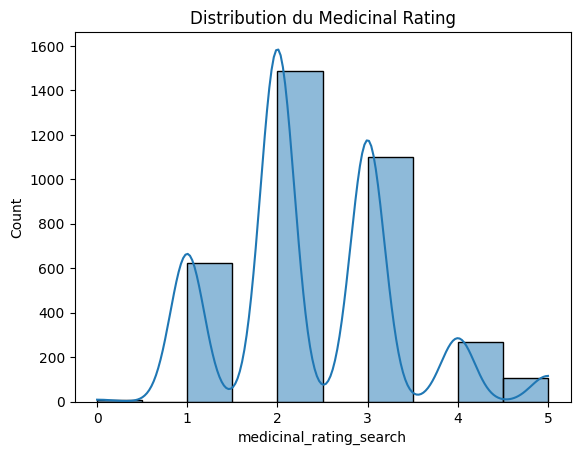

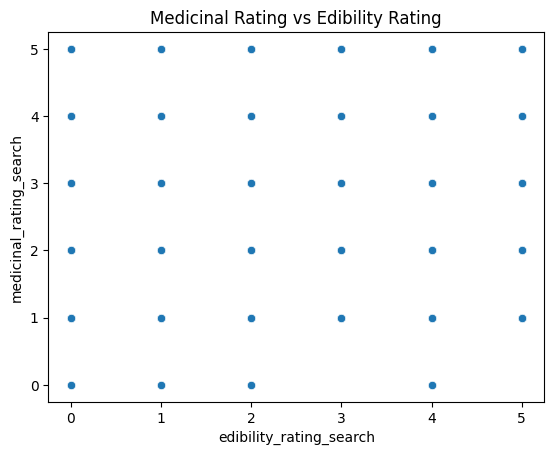

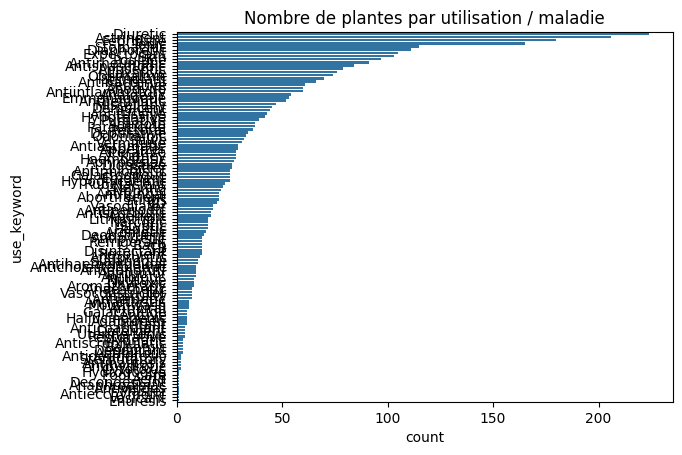

In [8]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Charger le dataset
df = pd.read_csv("pfaf_plants_merged.csv")

# Réduire le dataset pour accélérer (ex: 20% aléatoire)
df_small = df.sample(frac=0.2, random_state=42)

# Afficher les premières lignes
print(df_small.head())

# Infos générales
print(df_small.info())

# Statistiques descriptives
print(df_small.describe(include="all"))

# Vérification des valeurs manquantes
missing = df_small.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing[missing>0])

# Exemple de visualisation : distribution des ratings
sns.histplot(df_small['medicinal_rating_search'].dropna(), bins=10, kde=True)
plt.title("Distribution du Medicinal Rating")
plt.show()

# Relation 'medicinal_rating_search' vs 'edibility_rating_search'
sns.scatterplot(data=df_small, x='edibility_rating_search', y='medicinal_rating_search')
plt.title("Medicinal Rating vs Edibility Rating")
plt.show()

# Répartition par maladie / utilisation
sns.countplot(y='use_keyword', data=df_small, order=df_small['use_keyword'].value_counts().index)
plt.title("Nombre de plantes par utilisation / maladie")
plt.show()


In [3]:
#Étape 2 : Construction du modèle
#2.1 Préparation des données
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# On veut prédire 'use_keyword' (maladie / utilisation) à partir des autres colonnes
TARGET = 'use_keyword'

# On supprime la colonne cible et certaines colonnes inutiles pour le modèle
X = df.drop(columns=[TARGET, 'plant_url', 'Image URLs', 'Common Names', 'Common Name', 'latin_name_search'])
y = df[TARGET]

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Séparer colonnes numériques et catégorielles
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object','category','bool']).columns.tolist()

# Préprocessing
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='mean'), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])


In [4]:
#2.2 Choix du modèle
#Ici,RandomForestClassifier est adapté pour un problème de classification multi-classes(différentes maladies/utilisations)
#On crée un pipeline complet : preprocessing + modèle
clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])
# Entraînement
clf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['edibility_rating_search',
                                                   'medicinal_rating_search',
                                                   'Edibility Rating',
                                                   'Medicinal Rating',
                                                   'Other Uses Rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['common_name_search',
                                                   'Care Requirements',
                                                   'Cultivation Details',
                                                   'Edible Uses', 'Family',
                                                   'Known Hazards',
                                                   'Medicinal Properties',
                                                   'Native Range', 'Other Uses',
                                                   'Propagation', 'Range',
                                                   'Scientific Name',
                                                   'Special Uses', 'Summary',
                                                   'USDA hardiness',
                                                   'Weed Potential'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

Accuracy : 0.1966573816155989
Classification Report:
                      precision    recall  f1-score   support

      Abortifacient       0.00      0.00      0.00        19
              Acrid       0.00      0.00      0.00         4
          Adaptogen       0.00      0.00      0.00         5
         Alterative       0.05      0.04      0.04        28
        Anaesthetic       0.00      0.00      0.00         7
          Analgesic       0.22      0.25      0.24        55
      Anaphrodisiac       0.00      0.00      0.00         2
            Anodyne       0.24      0.29      0.26        62
            Antacid       0.00      0.00      0.00         2
       Anthelmintic       0.09      0.08      0.08        51
        Antiaphonic       0.00      0.00      0.00         2
      Antiarthritic       0.25      0.11      0.15         9
      Antiasthmatic       0.10      0.10      0.10        30
      Antibacterial       0.21      0.30      0.25        66
        Antibilious       0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


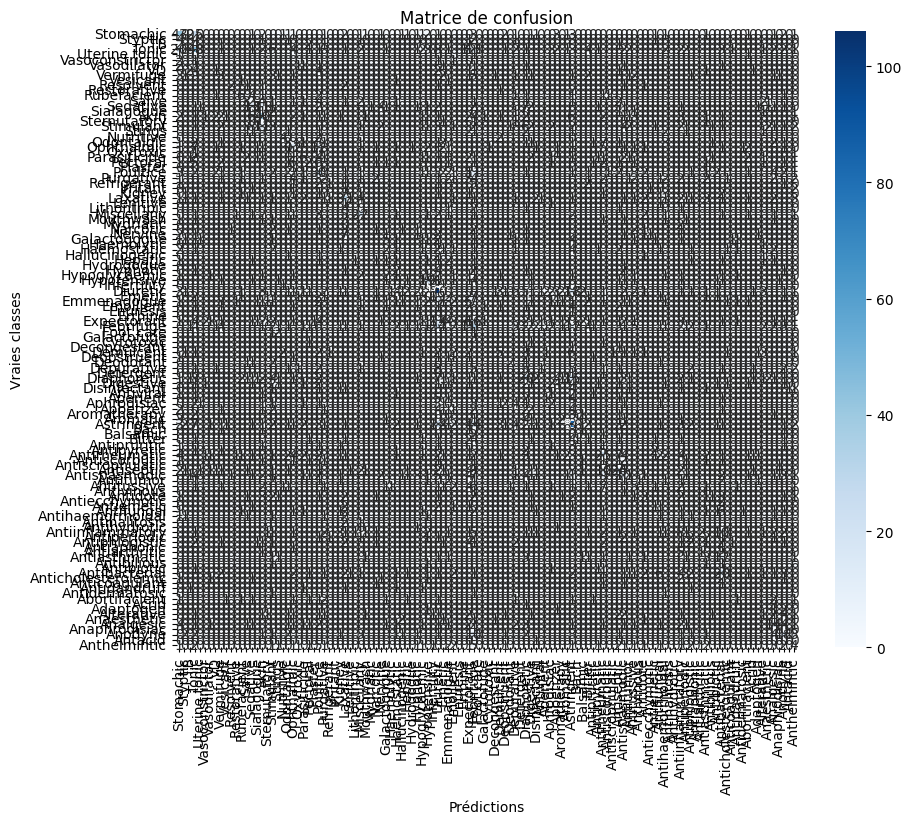

In [5]:
#Étape 3 : Évaluation du modèle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prédiction
y_pred = clf_pipeline.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

# Rapport classification
print("Classification Report:\n", classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=y.unique())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=y.unique(), yticklabels=y.unique(), cmap="Blues")
plt.ylabel("Vraies classes")
plt.xlabel("Prédictions")
plt.title("Matrice de confusion")
plt.show()